In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
import pymupdf4llm

file_path = 'data/ai-maturity-matrix-nov-2024.pdf'

md_text = pymupdf4llm.to_markdown(
    doc=file_path,
    page_chunks=True,
    show_progress=True,
    write_images=True,
    image_path='output/images',
    image_format='png'
)

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
Processing data/ai-maturity-matrix-nov-2024.pdf...


100%|██████████| 23/23 [00:12<00:00,  1.89it/s]


In [5]:
print(md_text[1]['text'])

### Contents

#### 03  Introduction 04 Key Findings 05 The Relationship Between Exposure and Readiness 10  The Archetypes of AI Adoption 15  Strategic Next Steps 17  Methodology 21  About the Authors





In [6]:
md_text[0]

{'metadata': {'format': 'PDF 1.4',
  'title': '',
  'author': '',
  'subject': '',
  'keywords': '',
  'creator': 'Adobe InDesign 19.5 (Macintosh)',
  'producer': 'Adobe PDF Library 17.0',
  'creationDate': "D:20241115111150-06'00'",
  'modDate': "D:20241115111159-06'00'",
  'trapped': '',
  'encryption': None,
  'file_path': 'data/ai-maturity-matrix-nov-2024.pdf',
  'page_count': 23,
  'page': 1},
 'toc_items': [],
 'tables': [],
 'images': [{'number': 1,
   'bbox': Rect(0.0, 0.0, 596.0, 482.0),
   'transform': (596.0, 0.0, 0.0, 482.0, 0.0, 0.0),
   'width': 596,
   'height': 482,
   'colorspace': 3,
   'cs-name': 'DeviceRGB',
   'xres': 96,
   'yres': 96,
   'bpc': 8,
   'size': 0,
   'has-mask': False},
  {'number': 2,
   'bbox': Rect(0.0, 666.0, 596.0, 842.0),
   'transform': (596.0, 0.0, 0.0, 176.0, 0.0, 666.0),
   'width': 596,
   'height': 176,
   'colorspace': 3,
   'cs-name': 'DeviceRGB',
   'xres': 96,
   'yres': 96,
   'bpc': 8,
   'size': 0,
   'has-mask': False}],
 'graphi

In [7]:
for page, text in enumerate(md_text[0:4]):
    print(f"**page {page+1}**\n{'='*20}")
    print(f'{text['text'][:100]}....')

**page 1**
![](output/images/ai-maturity-matrix-nov-2024.pdf-0-full.png)

![](output/images/ai-maturity-matrix-....
**page 2**
### Contents

#### 03  Introduction 04 Key Findings 05 The Relationship Between Exposure and Readin....
**page 3**
![](output/images/ai-maturity-matrix-nov-2024.pdf-2-0.png)
### Introduction

iews vary on how much A....
**page 4**
**Key Findings**


**Out of 73 economies assessed, only**
**five—Canada, Mainland China,**
**Singapo....


In [8]:
from langchain_upstage import UpstageDocumentParseLoader

loader = UpstageDocumentParseLoader(
    file_path=file_path, split='page',
    output_format='markdown',
    base64_encoding=['figure', 'chart', 'table']
)

docs = loader.load_and_split()

In [9]:
print((docs[:4]))

[Document(metadata={'page': 1, 'base64_encodings': [], 'coordinates': [[{'x': 0.0585, 'y': 0.0507}, {'x': 0.7442, 'y': 0.0507}, {'x': 0.7442, 'y': 0.0938}, {'x': 0.0585, 'y': 0.0938}], [{'x': 0.0572, 'y': 0.1427}, {'x': 0.4313, 'y': 0.1427}, {'x': 0.4313, 'y': 0.1615}, {'x': 0.0572, 'y': 0.1615}], [{'x': 0.0587, 'y': 0.2034}, {'x': 0.5395, 'y': 0.2034}, {'x': 0.5395, 'y': 0.2617}, {'x': 0.0587, 'y': 0.2617}]]}, page_content='The AI Maturity Matrix Which Economies Are Ready for AI? November 2024\nBy Christian Schwaerzler, Miguel Carrasco, Christopher Daniel,\nBrooke Bollyky, Yoshihisa Niwa, Aparna Bharadwaj, Akram Awad,\nRichard Sargeant, Sanjay Nawandhar, and Svetlana Kostikova'), Document(metadata={'page': 2, 'base64_encodings': [], 'coordinates': [[{'x': 0.0566, 'y': 0.0406}, {'x': 0.2804, 'y': 0.0406}, {'x': 0.2804, 'y': 0.0788}, {'x': 0.0566, 'y': 0.0788}], [{'x': 0.0538, 'y': 0.1866}, {'x': 0.3537, 'y': 0.1866}, {'x': 0.3537, 'y': 0.2219}, {'x': 0.0538, 'y': 0.2219}], [{'x': 0.053

In [10]:
for i, j in enumerate(docs[1:5]):
    bs_encoding = j.metadata['base64_encodings']
    if len(bs_encoding) > 0:
        print(f'**page {i+1}**\n{'='*20}')
        print(f'**page content preview:** {j.page_content[:100]}....')
        print(f'**metadata keys:** {', '.join(j.metadata.keys())}')
        print(f'**base64 encoding (preview):** {bs_encoding[0][:10]}....')
        print('\n')

**page 3**
**page content preview:** Key Findings Out of 73 economies assessed, only
five—Canada, Mainland China,
Singapore, the UK, and ....
**metadata keys:** page, base64_encodings, coordinates
**base64 encoding (preview):** /9j/2wCEAA....




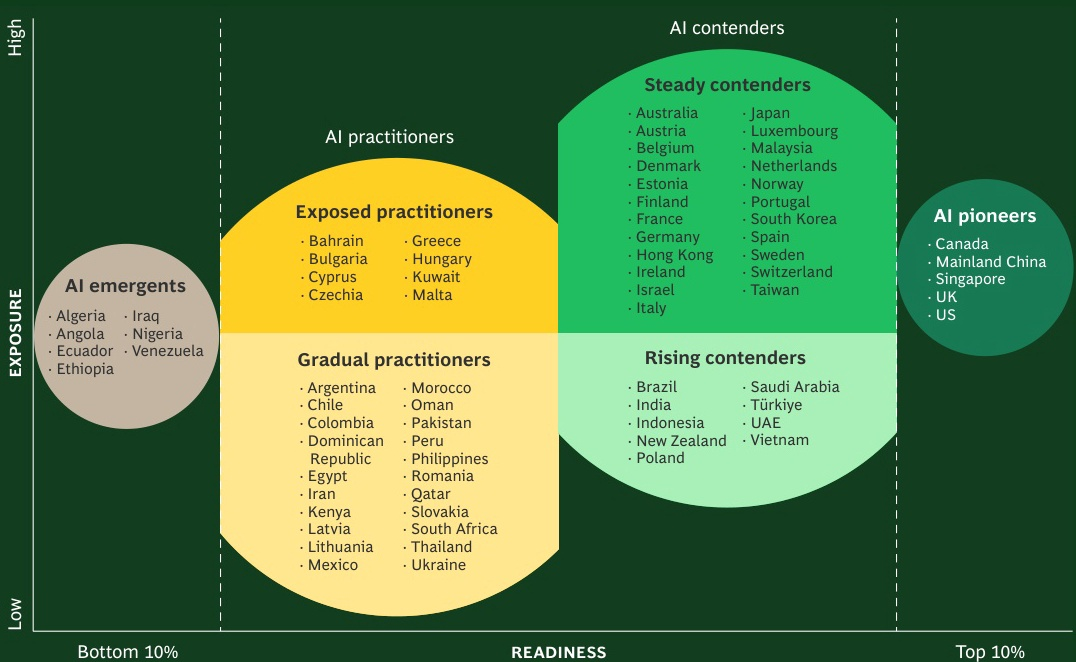

In [11]:
import base64
from IPython.display import Image, display

img_data = base64.b64decode(docs[3].metadata['base64_encodings'][0])
display(Image(data=img_data))

In [20]:
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.documents import Document
import os

llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash',
    api_key=os.getenv('GOOGLE_API_KEY')
)

def create_image_descriptions(docs):
    model = llm
    new_documents = []
    for doc in docs:
        if 'base64_encodings' in doc.metadata and len(doc.metadata['base64_encodings']) > 0:
            for idx, img_base64 in enumerate(doc.metadata['base64_encodings']):
                message = HumanMessage(
                    content=[
                        {
                            "type": 'text',
                            'text': """
                                        Describe only the factual content visible in the image:

                                        1. If decorative/non-informational: output '<---image--->'

                                        2. For content images:
                                        - General Images: List visible objects, text, and measurable attributes
                                        - Charts/Infographics: State all numerical values and labels present
                                        - Tables: Convert to markdown table format with exact data

                                        Rules:
                                        * Include only directly observable information
                                        * Use original numbers and text without modification
                                        * Avoid any interpretation or analysis
                                        * Preserve all labels and measurements exactly as shown
                                    """
                        },
                        {
                            'type': 'image_url',
                            'image_url':  {"url": f"data:image/jpeg;base64,{img_base64}"},
                        },
                    ]
                )

                response = model.invoke([message])

                new_doc = Document(
                    page_content=response.content,
                    metadata={
                        'page': f"{doc.metadata.get('page', 'unknown')}"
                    }
                )

    new_documents.append(new_doc)
image_description_docs = create_image_descriptions(docs)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 58.219819973s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [18]:
print(image_description_docs)

None


In [13]:
from langchain_core.documents import Document
from collections import defaultdict

def merge_text_and_images(md_text, image_description_docs):
    page_contents = defaultdict(list)
    page_metadata = {}

    for text_item in md_text:
        page = int(text_item['metadata']['page'])
        page_contents[page].append(text_item['text'])

        if page not in page_metadata:
            page_metadata[page] = {
                'source': text_item['metadata']['file_path'],
                'page': page
            }
    for img_doc in image_description_docs:
        page = int(img_doc.metadata['page'])
        page_contents[page].append(img_doc.page_content)
    merged_docs = []
    for page in sorted(page_contents.keys()):
        # Combine all content of the page into a single string
        full_content = '\n\n'.join(page_contents[page])
        
        # Create a Document object
        doc = Document(
            page_content=full_content,
            metadata=page_metadata[page]
        )
        merged_docs.append(doc)
    
    return merged_docs

In [19]:
merged_documents = merge_text_and_images(md_text, image_description_docs)

TypeError: 'NoneType' object is not iterable